In [36]:
# ==================
# Imports and Setup
# ==================

# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Data
df = pd.read_csv("ph_clean.csv")

# Plot Style
PALETTE = {
    "acid": "#8B0000",       # red
    "neutral": "#2E7D32",    # green
    "alkaline": "#1E88E5",   # blue
    "sand": "#F5E6C4",
    "charcoal": "#2B2B2B"
}

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.facecolor": PALETTE["sand"],
    "figure.facecolor": PALETTE["sand"],
    "text.color": PALETTE["charcoal"]
})

# Classifier Colors
# Color Mapping
color_map = {
    "Acidic": "#8B0000",    # red
    "Neutral": "#2E7D32",   # green
    "Alkaline": "#1E88E5"   # blue
}

def clean_plot():
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()

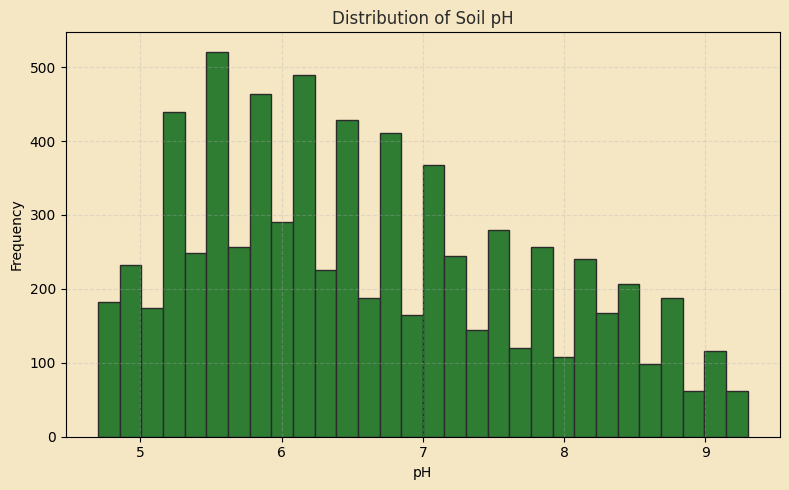

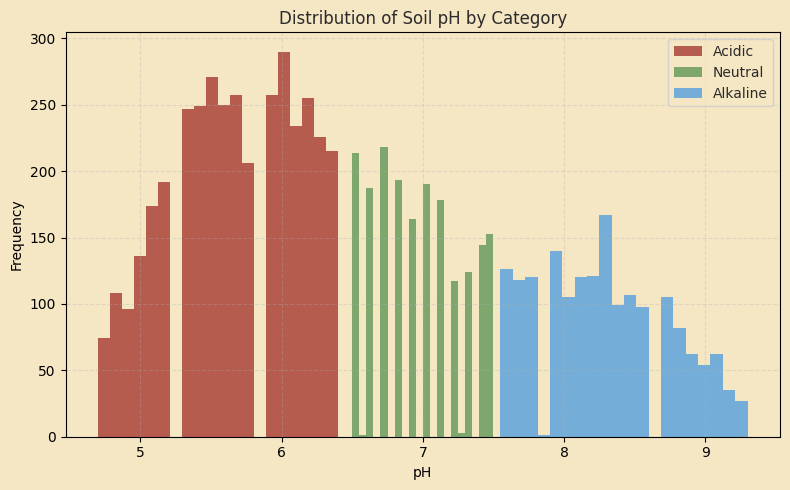

In [8]:
# pH Distribution

plt.hist(
    df['value_avg'],
    bins=30,
    color=PALETTE["neutral"],
    edgecolor=PALETTE["charcoal"]
)

plt.title("Distribution of Soil pH")
plt.xlabel("pH")
plt.ylabel("Frequency")

clean_plot()
plt.show()

# Add Categorical Overlay
for category in ["Acidic", "Neutral", "Alkaline"]:
    subset = df[df['ph_category'] == category]
    
    plt.hist(
        subset['value_avg'],
        bins=20,
        alpha=0.6,
        label=category,
        color=color_map[category]
    )

plt.title("Distribution of Soil pH by Category")
plt.xlabel("pH")
plt.ylabel("Frequency")

plt.legend()
clean_plot()
plt.show()

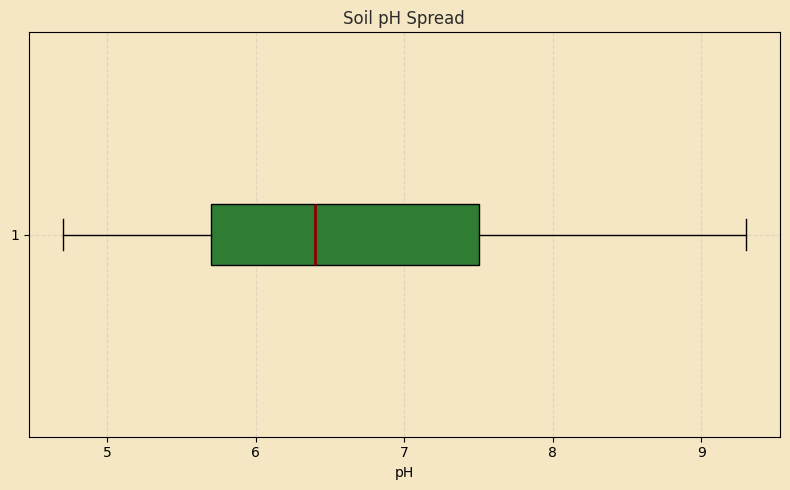

In [10]:
# Box Plot

plt.boxplot(
    df['value_avg'],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor=PALETTE["neutral"]),
    medianprops=dict(color=PALETTE["acid"], linewidth=2)
)

plt.title("Soil pH Spread")
plt.xlabel("pH")

clean_plot()
plt.show()

C:\Users\rfull\AppData\Local\Temp\ipykernel_41456\3226240419.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


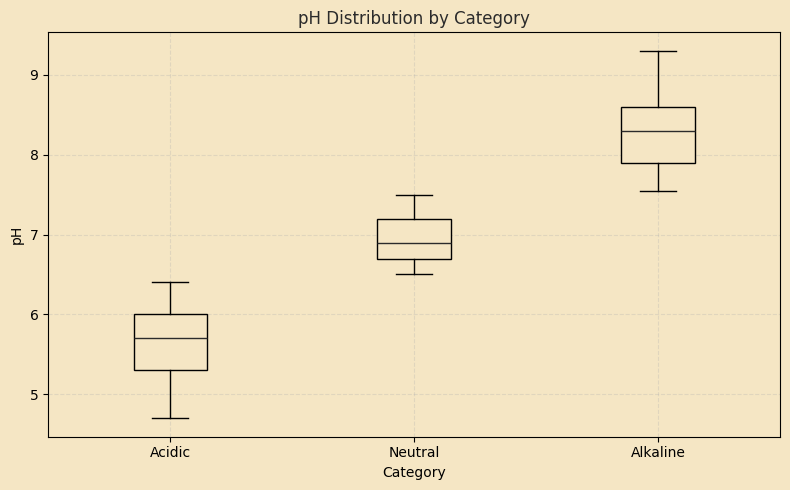

In [24]:
# Categorical Box Plots
data = [
    df[df['ph_category'] == cat]['value_avg']
    for cat in ["Acidic", "Neutral", "Alkaline"]
]

plt.boxplot(
    data,
    patch_artist=True,
    labels=["Acidic", "Neutral", "Alkaline"],
    boxprops=dict(facecolor="#F5E6C4"),
    medianprops=dict(color="#2B2B2B")
)

# Color boxes manually
for patch, cat in zip(plt.gca().artists, ["Acidic", "Neutral", "Alkaline"]):
    patch.set_facecolor(color_map[cat])

plt.title("pH Distribution by Category")
plt.xlabel("Category")
plt.ylabel("pH")

clean_plot()
plt.show()

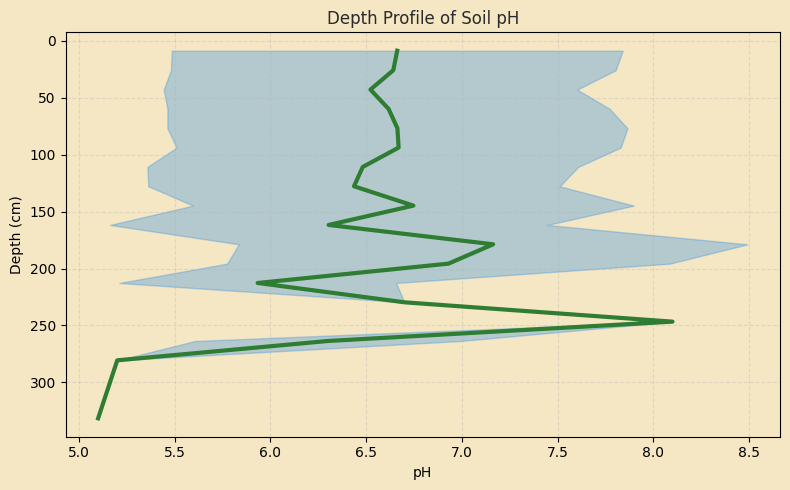

In [18]:
# Depth Profile Curve

df['depth_bin'] = pd.cut(df['depth_mid'], bins=20)

depth_stats = df.groupby('depth_bin')['value_avg'].agg(['mean', 'std']).reset_index()
depth_stats['depth_mid_bin'] = depth_stats['depth_bin'].apply(lambda x: x.mid)

plt.plot(
    depth_stats['mean'],
    depth_stats['depth_mid_bin'],
    color=PALETTE["neutral"],
    linewidth=3
)

plt.fill_betweenx(
    depth_stats['depth_mid_bin'],
    depth_stats['mean'] - depth_stats['std'],
    depth_stats['mean'] + depth_stats['std'],
    color=PALETTE["alkaline"],
    alpha=0.3
)

plt.gca().invert_yaxis()

plt.title("Depth Profile of Soil pH")
plt.xlabel("pH")
plt.ylabel("Depth (cm)")

clean_plot()
plt.show()

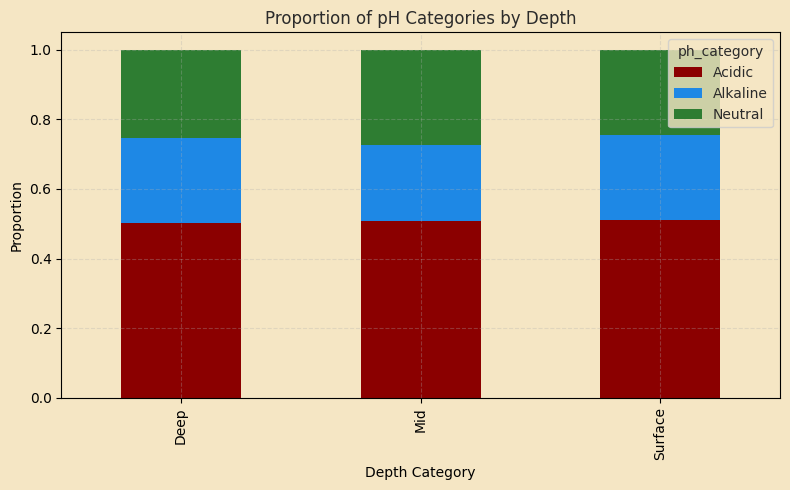

In [20]:
# Category by Depth
cross = pd.crosstab(df['depth_category'], df['ph_category'], normalize='index')

cross.plot(
    kind='bar',
    stacked=True,
    color=[color_map[c] for c in cross.columns]
)

plt.title("Proportion of pH Categories by Depth")
plt.xlabel("Depth Category")
plt.ylabel("Proportion")

clean_plot()
plt.show()

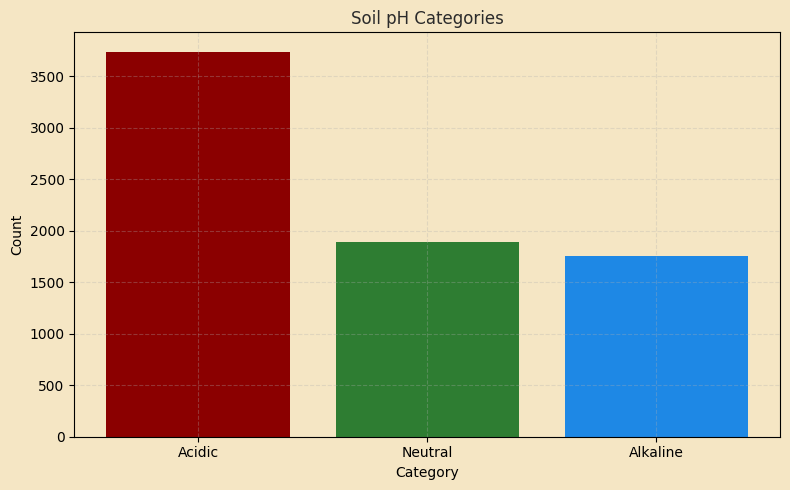

In [26]:
# pH Distribution

counts = df['ph_category'].value_counts()

colors = [
    PALETTE["acid"],
    PALETTE["neutral"],
    PALETTE["alkaline"]
]

plt.bar(counts.index, counts.values, color=colors)

plt.title("Soil pH Categories")
plt.xlabel("Category")
plt.ylabel("Count")

clean_plot()
plt.show()

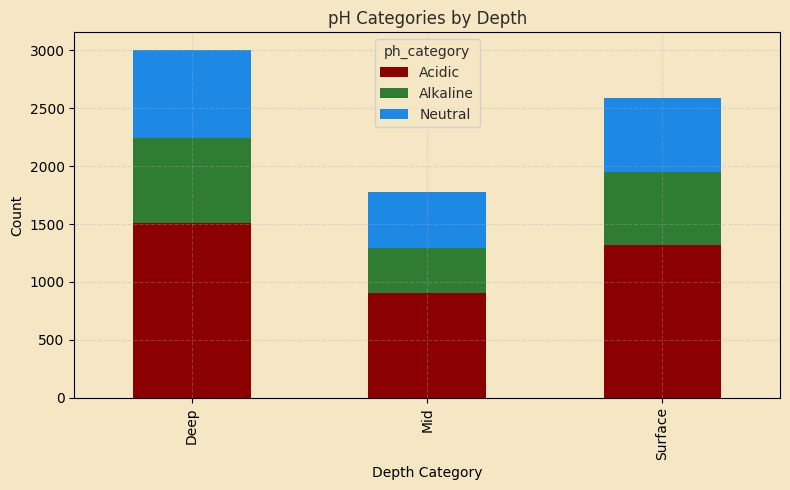

In [28]:
# Category by Depth

cross = pd.crosstab(df['depth_category'], df['ph_category'])

cross.plot(kind='bar', stacked=True, color=colors)

plt.title("pH Categories by Depth")
plt.xlabel("Depth Category")
plt.ylabel("Count")

clean_plot()
plt.show()

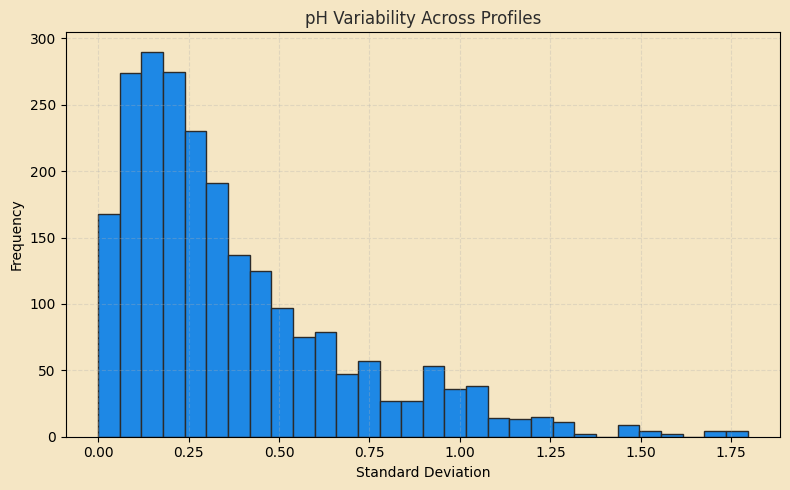

In [30]:
# Stability Analysis

ph_variability = df.groupby('profile_id')['value_avg'].std()

plt.hist(
    ph_variability.dropna(),
    bins=30,
    color=PALETTE["alkaline"],
    edgecolor=PALETTE["charcoal"]
)

plt.title("pH Variability Across Profiles")
plt.xlabel("Standard Deviation")
plt.ylabel("Frequency")

clean_plot()
plt.show()

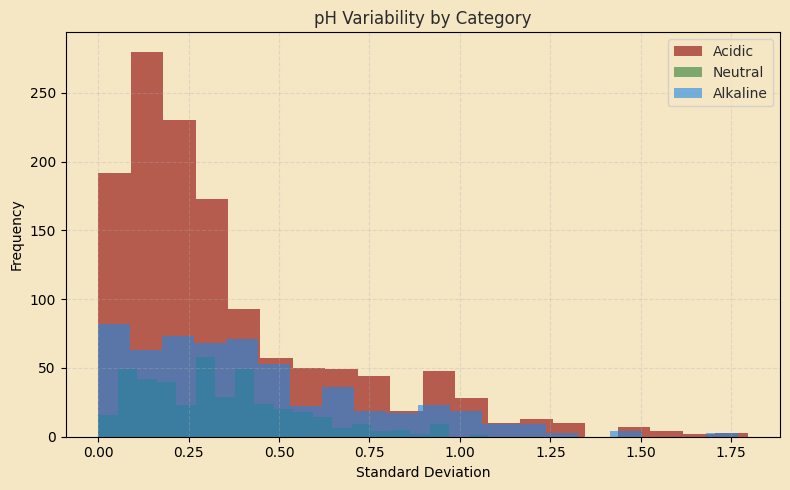

In [34]:
# Stability by Category

ph_variability = df.groupby('profile_id')['value_avg'].std()

# Merge category (use most common category per profile)
profile_category = df.groupby('profile_id')['ph_category'].agg(lambda x: x.mode()[0])

var_df = pd.DataFrame({
    'std': ph_variability,
    'category': profile_category
}).dropna()

for category in ["Acidic", "Neutral", "Alkaline"]:
    subset = var_df[var_df['category'] == category]
    
    plt.hist(
        subset['std'],
        bins=20,
        alpha=0.6,
        label=category,
        color=color_map[category]
    )

plt.title("pH Variability by Category")
plt.xlabel("Standard Deviation")
plt.ylabel("Frequency")

plt.legend()
clean_plot()
plt.show()